# Перевод реальных данных в гиперкуб

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import math
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 140


from tqdm.notebook import tqdm
from torchvision import transforms
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import euclidean_distances
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage
from scipy.stats import norm

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)


class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.gelu(self.linear1(z))
        z = torch.tanh(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))


class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
data_path = '/content/drive/MyDrive/cursach-hse'

In [ ]:
class CustomMnistDataset(torch.utils.data.Dataset):
    """
    Reads the MNIST data from csv file given file path.
    """
    def __init__(self, csv_path, num_datapoints = None):
        super(CustomMnistDataset, self).__init__()

        self.df = pd.read_csv(csv_path)

        # Will be useful later while evaluating
        if num_datapoints is not None:
            self.df = self.df.iloc[0:num_datapoints]

    def __len__(self):
        return len(self.df)

    def  __getitem__(self, index):
        # Read
        img = self.df.iloc[index].filter(regex='pixel').values
        img =  np.reshape(img, (28, 28)).astype(np.uint8)

        # Convert to Tensor
        img_tensor = transforms.ToTensor()(img) # [0, 1]
        # img_tensor = 2*img_tensor - 1 # [-1, 1]
        img_tensor = transforms.Normalize((0.5,), (0.5,))(img_tensor)

        return img_tensor

In [ ]:
!unzip /content/drive/MyDrive/cursach-hse/mnist_data/train.csv.zip

Archive:  /content/drive/MyDrive/cursach-hse/mnist_data/train.csv.zip
  inflating: train.csv               


In [ ]:
train_csv_path = '/content/train.csv'
# batch_size = 1

trainset = CustomMnistDataset(train_csv_path)
# train_loader = torch.utils.data.DataLoader(
#     trainset, batch_size=batch_size, shuffle=False, drop_last=False
# )

## DDPM

In [ ]:
class DiffusionForwardProcess:

    r"""

    Forward Process class as described in the
    paper "Denoising Diffusion Probabilistic Models"

    """

    def __init__(self,
                 num_time_steps = 1000,
                 beta_start = 1e-4,
                 beta_end = 0.02
                ):

        # Precomputing beta, alpha, and alpha_bar for all t's.
        self.betas = torch.linspace(beta_start, beta_end, num_time_steps)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1 - self.alpha_bars)

    def add_noise(self, original, noise, t):

        r""" Adds noise to a batch of original images at time-step t.

        :param original: Input Image Tensor
        :param noise: Random Noise Tensor sampled from Normal Dist N(0, 1)
        :param t: timestep of the forward process of shape -> (B, )

        Note: time-step t may differ for each image inside the batch.

        """

        sqrt_alpha_bar_t = self.sqrt_alpha_bars.to(original.device)[t]
        sqrt_one_minus_alpha_bar_t = self.sqrt_one_minus_alpha_bars.to(original.device)[t]

        # Broadcast to multiply with the original image.
        sqrt_alpha_bar_t = sqrt_alpha_bar_t[:, None, None, None]
        sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar_t[:, None, None, None]

        # Return
        return (sqrt_alpha_bar_t * original) \
                           + \
               (sqrt_one_minus_alpha_bar_t * noise)


class DiffusionReverseProcess:

    r"""

    Reverse Process class as described in the
    paper "Denoising Diffusion Probabilistic Models"

    """

    def __init__(self,
                 num_time_steps = 1000,
                 beta_start = 1e-4,
                 beta_end = 0.02
                ):

        # Precomputing beta, alpha, and alpha_bar for all t's.
        self.b = torch.linspace(beta_start, beta_end, num_time_steps) # b -> beta
        self.a = 1 - self.b # a -> alpha
        self.a_bar = torch.cumprod(self.a, dim=0) # a_bar = alpha_bar

    def sample_prev_timestep(self, xt, noise_pred, t):

        r""" Sample x_(t-1) given x_t and noise predicted
             by model.

             :param xt: Image tensor at timestep t of shape -> B x C x H x W
             :param noise_pred: Noise Predicted by model of shape -> B x C x H x W
             :param t: Current time step

        """

        # Original Image Prediction at timestep t
        x0 = xt - (torch.sqrt(1 - self.a_bar.to(xt.device)[t]) * noise_pred)
        x0 = x0/torch.sqrt(self.a_bar.to(xt.device)[t])
        x0 = torch.clamp(x0, -1., 1.)

        # mean of x_(t-1)
        mean = (xt - ((1 - self.a.to(xt.device)[t]) * noise_pred)/(torch.sqrt(1 - self.a_bar.to(xt.device)[t])))
        mean = mean/(torch.sqrt(self.a.to(xt.device)[t]))

        # only return mean
        if t == 0:
            return mean, x0

        else:
            variance =  (1 - self.a_bar.to(xt.device)[t-1])/(1 - self.a_bar.to(xt.device)[t])
            variance = variance * self.b.to(xt.device)[t]
            sigma = variance**0.5
            z = torch.randn(xt.shape).to(xt.device)

            return mean + sigma * z, x0


def get_time_embedding(
    time_steps: torch.Tensor,
    t_emb_dim: int
) -> torch.Tensor:

    """
    Transform a scalar time-step into a vector representation of size t_emb_dim.

    :param time_steps: 1D tensor of size -> (Batch,)
    :param t_emb_dim: Embedding Dimension -> for ex: 128 (scalar value)

    :return tensor of size -> (B, t_emb_dim)
    """

    assert t_emb_dim%2 == 0, "time embedding must be divisible by 2."

    factor = 2 * torch.arange(start = 0,
                              end = t_emb_dim//2,
                              dtype=torch.float32,
                              device=time_steps.device
                             ) / (t_emb_dim)

    factor = 10000**factor

    t_emb = time_steps[:,None] # B -> (B, 1)
    t_emb = t_emb/factor # (B, 1) -> (B, t_emb_dim//2)
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=1) # (B , t_emb_dim)

    return t_emb


class NormActConv(nn.Module):
    """
    Perform GroupNorm, Activation, and Convolution operations.
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 num_groups:int = 8,
                 kernel_size: int = 3,
                 norm:bool = True,
                 act:bool = True
                ):
        super(NormActConv, self).__init__()

        # GroupNorm
        self.g_norm = nn.GroupNorm(
            num_groups,
            in_channels
        ) if norm is True else nn.Identity()

        # Activation
        self.act = nn.SiLU() if act is True else nn.Identity()

        # Convolution
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size,
            padding=(kernel_size - 1)//2
        )

    def forward(self, x):
        x = self.g_norm(x)
        x = self.act(x)
        x = self.conv(x)
        return x

#-----------------------------------------------------------------

class TimeEmbedding(nn.Module):
    """
    Maps the Time Embedding to the Required output Dimension.
    """
    def __init__(self,
                 n_out:int, # Output Dimension
                 t_emb_dim:int = 128 # Time Embedding Dimension
                ):
        super(TimeEmbedding, self).__init__()

        # Time Embedding Block
        self.te_block = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, n_out)
        )

    def forward(self, x):
        return self.te_block(x)

#---------------------------------------------------------------

class SelfAttentionBlock(nn.Module):
    """
    Perform GroupNorm and Multiheaded Self Attention operation.
    """
    def __init__(self,
                 num_channels:int,
                 num_groups:int = 8,
                 num_heads:int = 4,
                 norm:bool = True
                ):
        super(SelfAttentionBlock, self).__init__()

        # GroupNorm
        self.g_norm = nn.GroupNorm(
            num_groups,
            num_channels
        ) if norm is True else nn.Identity()

        # Self-Attention
        self.attn = nn.MultiheadAttention(
            num_channels,
            num_heads,
            batch_first=True
        )

    def forward(self, x):
        batch_size, channels, h, w = x.shape
        x = x.reshape(batch_size, channels, h*w)
        x = self.g_norm(x)
        x = x.transpose(1, 2)
        x, _ = self.attn(x, x, x)
        x = x.transpose(1, 2).reshape(batch_size, channels, h, w)
        return x

#----------------------------------------------------------------

class Downsample(nn.Module):
    """
    Perform Downsampling by the factor of k across Height and Width.
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 k:int = 2, # Downsampling factor
                 use_conv:bool = True, # If Downsampling using conv-block
                 use_mpool:bool = True # If Downsampling using max-pool
                ):
        super(Downsample, self).__init__()

        self.use_conv = use_conv
        self.use_mpool = use_mpool

        # Downsampling using Convolution
        self.cv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=1),
            nn.Conv2d(
                in_channels,
                out_channels//2 if use_mpool else out_channels,
                kernel_size=4,
                stride=k,
                padding=1
            )
        ) if use_conv else nn.Identity()

        # Downsampling using Maxpool
        self.mpool = nn.Sequential(
            nn.MaxPool2d(k, k),
            nn.Conv2d(
                in_channels,
                out_channels//2 if use_conv else out_channels,
                kernel_size=1,
                stride=1,
                padding=0
            )
        ) if use_mpool else nn.Identity()

    def forward(self, x):

        if not self.use_conv:
            return self.mpool(x)

        if not self.use_mpool:
            return self.cv(x)

        return torch.cat([self.cv(x), self.mpool(x)], dim=1)

#-----------------------------------------------------------------------

class Upsample(nn.Module):
    """
    Perform Upsampling by the factor of k across Height and Width
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 k:int = 2, # Upsampling factor
                 use_conv:bool = True, # Upsampling using conv-block
                 use_upsample:bool = True # Upsampling using nn.upsample
                ):
        super(Upsample, self).__init__()

        self.use_conv = use_conv
        self.use_upsample = use_upsample

        # Upsampling using conv
        self.cv = nn.Sequential(
            nn.ConvTranspose2d(
                in_channels,
                out_channels//2 if use_upsample else out_channels,
                kernel_size=4,
                stride=k,
                padding=1
            ),
            nn.Conv2d(
                out_channels//2 if use_upsample else out_channels,
                out_channels//2 if use_upsample else out_channels,
                kernel_size = 1,
                stride=1,
                padding=0
            )
        ) if use_conv else nn.Identity()

        # Upsamling using nn.Upsample
        self.up = nn.Sequential(
            nn.Upsample(
                scale_factor=k,
                mode = 'bilinear',
                align_corners=False
            ),
            nn.Conv2d(
                in_channels,
                out_channels//2 if use_conv else out_channels,
                kernel_size=1,
                stride=1,
                padding=0
            )
        ) if use_upsample else nn.Identity()

    def forward(self, x):

        if not self.use_conv:
            return self.up(x)

        if not self.use_upsample:
            return self.cv(x)

        return torch.cat([self.cv(x), self.up(x)], dim=1)


class DownC(nn.Module):
    """
    Perform Down-convolution on the input using following approach.
    1. Conv + TimeEmbedding
    2. Conv
    3. Skip-connection from input x.
    4. Self-Attention
    5. Skip-Connection from 3.
    6. Downsampling
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 t_emb_dim:int = 128, # Time Embedding Dimension
                 num_layers:int=2,
                 down_sample:bool = True # True for Downsampling
                ):
        super(DownC, self).__init__()

        self.num_layers = num_layers

        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i==0 else out_channels,
                        out_channels
                       ) for i in range(num_layers)
        ])

        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers)
        ])

        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)
        ])

        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        self.down_block =Downsample(out_channels, out_channels) if down_sample else nn.Identity()

        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i==0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers)
        ])

    def forward(self, x, t_emb):

        out = x

        for i in range(self.num_layers):
            resnet_input = out

            # Resnet Block
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](resnet_input)

            # Self Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn

        # Downsampling
        out = self.down_block(out)

        return out


class MidC(nn.Module):
    """
    Refine the features obtained from the DownC block.
    It refines the features using following operations:

    1. Resnet Block with Time Embedding
    2. A Series of Self-Attention + Resnet Block with Time-Embedding
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 t_emb_dim:int = 128,
                 num_layers:int = 2
                ):
        super(MidC, self).__init__()

        self.num_layers = num_layers

        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i==0 else out_channels,
                        out_channels
                       ) for i in range(num_layers + 1)
        ])

        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers + 1)
        ])

        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers + 1)
        ])

        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i==0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers + 1)
        ])

    def forward(self, x, t_emb):
        out = x

        # First-Resnet Block
        resnet_input = out
        out = self.conv1[0](out)
        out = out + self.te_block[0](t_emb)[:, :, None, None]
        out = self.conv2[0](out)
        out = out + self.res_block[0](resnet_input)

        # Sequence of Self-Attention + Resnet Blocks
        for i in range(self.num_layers):

            # Self Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn

            # Resnet Block
            resnet_input = out
            out = self.conv1[i+1](out)
            out = out + self.te_block[i+1](t_emb)[:, :, None, None]
            out = self.conv2[i+1](out)
            out = out + self.res_block[i+1](resnet_input)

        return out


class UpC(nn.Module):
    """
    Perform Up-convolution on the input using following approach.
    1. Upsampling
    2. Conv + TimeEmbedding
    3. Conv
    4. Skip-connection from 1.
    5. Self-Attention
    6. Skip-Connection from 3.
    """
    def __init__(self,
                 in_channels:int,
                 out_channels:int,
                 t_emb_dim:int = 128, # Time Embedding Dimension
                 num_layers:int = 2,
                 up_sample:bool = True # True for Upsampling
                ):
        super(UpC, self).__init__()

        self.num_layers = num_layers

        self.conv1 = nn.ModuleList([
            NormActConv(in_channels if i==0 else out_channels,
                        out_channels
                       ) for i in range(num_layers)
        ])

        self.conv2 = nn.ModuleList([
            NormActConv(out_channels,
                        out_channels
                       ) for _ in range(num_layers)
        ])

        self.te_block = nn.ModuleList([
            TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)
        ])

        self.attn_block = nn.ModuleList([
            SelfAttentionBlock(out_channels) for _ in range(num_layers)
        ])

        self.up_block =Upsample(in_channels, in_channels//2) if up_sample else nn.Identity()

        self.res_block = nn.ModuleList([
            nn.Conv2d(
                in_channels if i==0 else out_channels,
                out_channels,
                kernel_size=1
            ) for i in range(num_layers)
        ])

    def forward(self, x, down_out, t_emb):

        # Upsampling
        x = self.up_block(x)
        x = torch.cat([x, down_out], dim=1)

        out = x
        for i in range(self.num_layers):
            resnet_input = out

            # Resnet Block
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](resnet_input)

            # Self Attention
            out_attn = self.attn_block[i](out)
            out = out + out_attn

        return out


class Unet(nn.Module):
    """
    U-net architecture which is used to predict noise
    in the paper "Denoising Diffusion Probabilistic Model".

    U-net consists of Series of DownC blocks followed by MidC
    followed by UpC.
    """

    def __init__(self,
                 im_channels: int = 1, # RGB
                 down_ch: list = [32, 64, 128, 256],
                 mid_ch: list = [256, 256, 128],
                 up_ch: list[int] = [256, 128, 64, 16],
                 down_sample: list[bool] = [True, True, False],
                 t_emb_dim: int = 128,
                 num_downc_layers:int = 2,
                 num_midc_layers:int = 2,
                 num_upc_layers:int = 2
                ):
        super(Unet, self).__init__()

        self.im_channels = im_channels
        self.down_ch = down_ch
        self.mid_ch = mid_ch
        self.up_ch = up_ch
        self.t_emb_dim = t_emb_dim
        self.down_sample = down_sample
        self.num_downc_layers = num_downc_layers
        self.num_midc_layers = num_midc_layers
        self.num_upc_layers = num_upc_layers

        self.up_sample = list(reversed(self.down_sample)) # [False, True, True]

        # Initial Convolution
        self.cv1 = nn.Conv2d(self.im_channels, self.down_ch[0], kernel_size=3, padding=1)

        # Initial Time Embedding Projection
        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        # DownC Blocks
        self.downs = nn.ModuleList([
            DownC(
                self.down_ch[i],
                self.down_ch[i+1],
                self.t_emb_dim,
                self.num_downc_layers,
                self.down_sample[i]
            ) for i in range(len(self.down_ch) - 1)
        ])

        # MidC Block
        self.mids = nn.ModuleList([
            MidC(
                self.mid_ch[i],
                self.mid_ch[i+1],
                self.t_emb_dim,
                self.num_midc_layers
            ) for i in range(len(self.mid_ch) - 1)
        ])

        # UpC Block
        self.ups = nn.ModuleList([
            UpC(
                self.up_ch[i],
                self.up_ch[i+1],
                self.t_emb_dim,
                self.num_upc_layers,
                self.up_sample[i]
            ) for i in range(len(self.up_ch) - 1)
        ])

        # Final Convolution
        self.cv2 = nn.Sequential(
            nn.GroupNorm(8, self.up_ch[-1]),
            nn.Conv2d(self.up_ch[-1], self.im_channels, kernel_size=3, padding=1)
        )

    def forward(self, x, t):

        out = self.cv1(x)

        # Time Projection
        t_emb = get_time_embedding(t, self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        # DownC outputs
        down_outs = []

        for down in self.downs:
            down_outs.append(out)
            out = down(out, t_emb)

        # MidC outputs
        for mid in self.mids:
            out = mid(out, t_emb)

        # UpC Blocks
        for up in self.ups:
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        # Final Conv
        out = self.cv2(out)

        return out

## DDIM

In [ ]:
class DDIM:
    def __init__(self, T, model, device):
        self.T = T
        self.function_approximator = model.to(device)
        self.device = device

        self.beta = torch.linspace(1e-4, 0.02, T).to(device)
        self.alpha = 1. - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    @torch.no_grad()
    def sampling(self, n_samples=1, image_channels=1, img_size=(28, 28),
                      n_steps=50, use_tqdm=True, initial_noise=None):

        step_size = self.T // n_steps
        if initial_noise is None:
            x = torch.randn((n_samples, image_channels, img_size[0], img_size[1]),
                        device=self.device)
            noise = x.detach().clone().cpu().numpy()
        else:
            x = torch.from_numpy(initial_noise).to(device)
            noise = None
        progress_bar = tqdm if use_tqdm else lambda x: x

        for i in progress_bar(range(n_steps)):
            t = self.T - i * step_size
            t_tensor = torch.ones(n_samples, dtype=torch.long, device=self.device) * t

            alpha_bar_t = self.alpha_bar[t - 1].unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
            alpha_bar_prev = self.alpha_bar[t - step_size - 1].unsqueeze(-1).unsqueeze(-1).unsqueeze(-1) if t > step_size else torch.tensor(1.0).to(self.device)

            # Predicted noise
            eps_pred = self.function_approximator(x, t_tensor - 1)

            # Predicted x_0
            x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)

            # Direction pointing to xt
            dir_xt = torch.sqrt(1 - alpha_bar_prev) * eps_pred

            # Update rule
            x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

        x = torch.clamp(x, -1., 1.).detach().cpu().numpy()

        return x, noise

## DDIMDiffable

In [ ]:
class DDIMDiffable(nn.Module):
    def __init__(self, T, model, device, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.T = T
        self.model = model.to(device)
        self.device = device

        beta = torch.linspace(beta_start, beta_end, T, device=device)
        alpha = 1. - beta
        alpha_bar = torch.cumprod(alpha, dim=0)

        self.register_buffer("beta", beta)
        self.register_buffer("alpha", alpha)
        self.register_buffer("alpha_bar", alpha_bar)

    def forward(self, xT, n_steps=50):
        """
        xT: (B,1,28,28) initial noise (this will be optimized)
        return: x0_hat in [-1,1]
        """
        B = xT.shape[0]
        step_size = self.T // n_steps
        x = xT

        for i in range(n_steps):
            t = self.T - i * step_size  # t = T, T-step, ..., step
            t_tensor = torch.full((B,), t - 1, dtype=torch.long, device=self.device)

            alpha_bar_t = self.alpha_bar[t - 1].view(1, 1, 1, 1)
            if t > step_size:
                alpha_bar_prev = self.alpha_bar[t - step_size - 1].view(1, 1, 1, 1)
            else:
                alpha_bar_prev = torch.ones((1, 1, 1, 1), device=self.device)

            eps_pred = self.model(x, t_tensor)

            x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
            dir_xt = torch.sqrt(1 - alpha_bar_prev) * eps_pred

            x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

        # return torch.clamp(x, -1., 1.)
        return x

## Hypercube $\leftrightarrow$ Gaussian

In [ ]:
def cube_to_gaussian(u, eps=1e-6):
    u = u.clamp(eps, 1 - eps)
    return math.sqrt(2.0) * torch.erfinv(2.0 * u - 1.0)

def gaussian_to_cube(z):
    return 0.5 * (1.0 + torch.erf(z / math.sqrt(2.0)))

## Invert batch of images to hypercube

In [ ]:
def invert_batch_to_cube(
    x0,                  # (B,1,28,28) in [-1,1]
    ddim: DDIMDiffable,
    ae: nn.Module,
    n_steps=50,
    iters=600,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
    eps_cube=1e-6,
    clamp_logits=10.0,
):
    """
    Returns:
      u_star:  (B,1,28,28) in (0,1)
      z_star:  (B,1,28,28) in R
      x0_hat:  (B,1,28,28) in [-1,1]
    """
    device = x0.device
    ddim.model.eval()
    ae.eval()

    with torch.no_grad():
        e_target = ae.encoder(x0)

    # logits s -> u=sigmoid(s)
    # s = torch.zeros_like(x0, device=device, requires_grad=True)  # starts at u=0.5
    s = torch.randn_like(x0, device=device, requires_grad=True)
    opt = torch.optim.Adam([s], lr=lr)

    best_loss = float("inf")
    best_u = best_z = best_x = None

    hist = {"total": [], "emb": [], "pix": [], "prior": []}

    for k in tqdm(range(iters)):
        u = torch.sigmoid(s)
        z = cube_to_gaussian(u, eps=eps_cube)

        x0_hat = ddim(z, n_steps=n_steps)
        e_hat = ae.encoder(x0_hat)

        loss_emb = F.mse_loss(e_hat, e_target)
        loss_pix = F.mse_loss(x0_hat, x0) if lambda_pix > 0 else 0.0
        loss_prior = z.pow(2).mean() if lambda_prior > 0 else 0.0

        loss = loss_emb + lambda_pix * loss_pix + lambda_prior * loss_prior

        hist["total"].append(float(loss.item()))
        hist["emb"].append(float(loss_emb.item()))
        hist["pix"].append(float(loss_pix.item()) if lambda_pix > 0 else 0.0)
        hist["prior"].append(float(loss_prior.item()) if lambda_prior > 0 else 0.0)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if clamp_logits is not None:
            s.data.clamp_(-clamp_logits, clamp_logits)

        L = float(loss.item())
        if L < best_loss:
            best_loss = L
            best_u = u.detach().clone()
            best_z = z.detach().clone()
            best_x = x0_hat.detach().clone()

        if (k+1) % 25 == 0:
            print(k+1, float(loss_emb.item()), float(loss_pix if isinstance(loss_pix,float) else loss_pix.item()))

    return best_u, best_z, best_x, best_loss, hist

In [ ]:
unet = torch.load('/content/drive/MyDrive/cursach-hse/ddpm_unet.pth', weights_only=False)

ae = Autoencoder(latent_dims=100).to(device)
ae.load_state_dict(torch.load(os.path.join(data_path, 'compare_two_unseen', 'ae_100dim_new.pth'), weights_only=True))

ddim = DDIMDiffable(T=1000, model=unet, device=device)

# x0 = next(iter(train_loader)).to(device)  # shape (B,1,28,28) in [-1,1] due to your Normalize
random_idx = 14139
x0 = trainset[random_idx].unsqueeze(0).to(device)

n_iters = 150  # 300 is good

u_star, z_star, x0_hat, best_loss, hist = invert_batch_to_cube(
    x0=x0,
    ddim=ddim,
    ae=ae,
    n_steps=50,
    iters=n_iters,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
)

print("best_loss:", best_loss)

  0%|          | 0/150 [00:00<?, ?it/s]

25 2.691579580307007 0.3396759033203125
50 2.220041513442993 0.2877768874168396
75 1.0847352743148804 0.1534874141216278
100 0.1225336492061615 0.025692608207464218
125 0.057792872190475464 0.014919362962245941
150 0.036131925880908966 0.00971761904656887
best_loss: 0.036655813455581665


In [ ]:
def plot_history(hist, title=None):
    plt.figure(figsize=(7,4))
    plt.plot(hist["total"], label="total")
    plt.plot(hist["emb"], label="emb")
    plt.plot(hist["pix"], label="pix")
    plt.plot(hist["prior"], label="prior")
    plt.yscale("log")
    plt.xlabel("iteration")
    plt.ylabel("loss (log scale)")
    plt.legend()
    if title: plt.title(title)
    plt.tight_layout()
    plt.show()

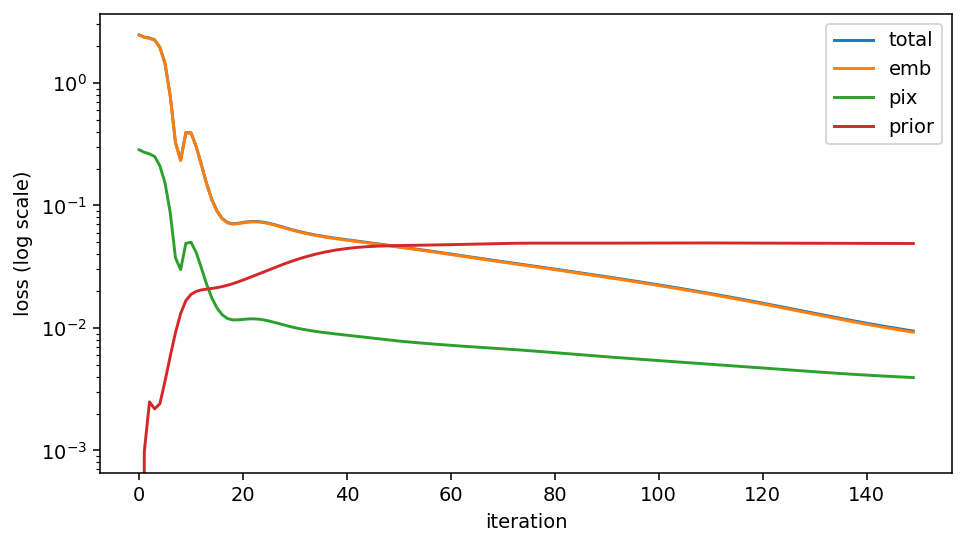

In [ ]:
plot_history(hist)

In [ ]:
with torch.no_grad():
    e0 = ae.encoder(x0)
    ehat = ae.encoder(x0_hat)
    print("embed MSE:", F.mse_loss(ehat, e0).item())

embed MSE: 0.036131925880908966


In [ ]:
with torch.no_grad():
    z2 = cube_to_gaussian(u_star)
    x2 = ddim(z2, n_steps=50)
    print("regen consistency:", F.mse_loss(x2, x0_hat).item())

regen consistency: 2.1402991141547534e-14


In [ ]:
with torch.no_grad():
    u = u_star.flatten(1)   # (B,784)
    print("u mean:", u.mean().item(), "target 0.5")
    print("u var :", u.var(unbiased=False).item(), "target", 1/12)

u mean: 0.4752222001552582 target 0.5
u var : 0.04444281384348869 target 0.08333333333333333


In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def to_img01(x):
    """(B,1,H,W) in [-1,1] -> (B,H,W) in [0,1] for plotting"""
    x = x.detach().cpu()
    x = (x + 1) / 2
    return x[:, 0].clamp(0, 1)

@torch.no_grad()
def show_triplets(x0, x0_hat, u_star, ddim, n_steps=50, max_n=8, title=None):
    """
    Shows rows: [original | optimized inversion | regen from u_star]
    """
    B = x0.shape[0]
    n = min(B, max_n)

    # regen from hypercube
    z = cube_to_gaussian(u_star[:n])
    x_regen = ddim(z, n_steps=n_steps)

    A = to_img01(x0[:n])
    Bimg = to_img01(x0_hat[:n])
    C = to_img01(x_regen)

    fig, axes = plt.subplots(n, 3, figsize=(6, 2*n))
    if n == 1:
        axes = axes[None, :]  # make it 2D

    for i in range(n):
        axes[i, 0].imshow(A[i], cmap="gray")
        axes[i, 0].set_title("x0")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(Bimg[i], cmap="gray")
        axes[i, 1].set_title("x0_hat (opt)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(C[i], cmap="gray")
        axes[i, 2].set_title("regen(u*)")
        axes[i, 2].axis("off")

    if title is not None:
        fig.suptitle(title, y=0.995)
    plt.tight_layout()
    plt.show()

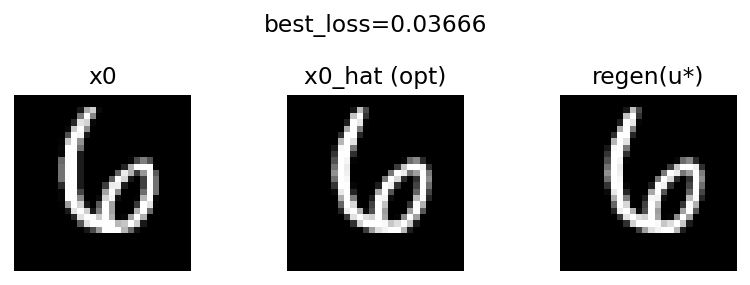

In [ ]:
show_triplets(x0, x0_hat, u_star, ddim, n_steps=50, max_n=8, title=f"best_loss={best_loss:.4g}")

In [ ]:
@torch.no_grad()
def print_metrics(x0, x0_hat, u_star, ddim, ae, n_steps=50):
    z = cube_to_gaussian(u_star)
    x_regen = ddim(z, n_steps=n_steps)

    e0 = ae.encoder(x0)
    ehat = ae.encoder(x0_hat)
    ereg = ae.encoder(x_regen)

    emb_hat = F.mse_loss(ehat, e0).item()
    emb_reg = F.mse_loss(ereg, e0).item()
    pix_hat = F.mse_loss(x0_hat, x0).item()
    pix_reg = F.mse_loss(x_regen, x0).item()
    regen_consistency = F.mse_loss(x_regen, x0_hat).item()

    print(f"Embedding MSE:  opt={emb_hat:.6f}  regen={emb_reg:.6f}")
    print(f"Pixel MSE:      opt={pix_hat:.6f}  regen={pix_reg:.6f}")
    print(f"Regen vs opt MSE: {regen_consistency:.6f}")

In [ ]:
print_metrics(x0, x0_hat, u_star, ddim, ae, n_steps=50)

Embedding MSE:  opt=0.036132  regen=0.036132
Pixel MSE:      opt=0.009718  regen=0.009718
Regen vs opt MSE: 0.000000


In [ ]:
@torch.no_grad()
def plot_cube_hist(u_star, bins=50, title="u* histogram"):
    u = u_star.detach().cpu().flatten().numpy()
    plt.figure(figsize=(6,3))
    plt.hist(u, bins=bins)
    plt.title(title)
    plt.tight_layout()
    plt.show()

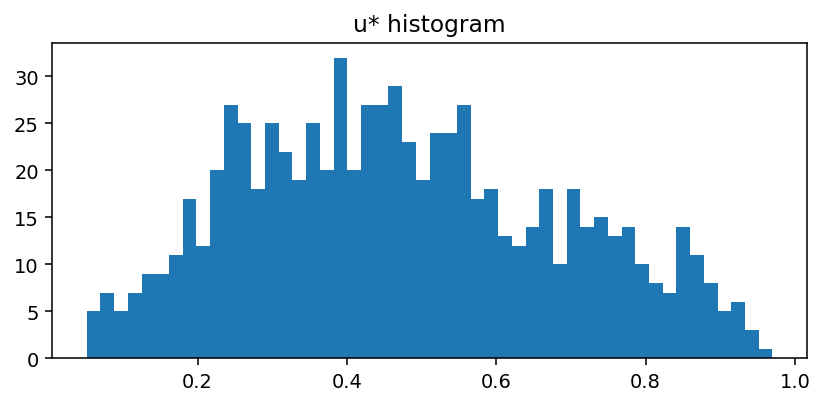

In [ ]:
plot_cube_hist(u_star)

## Sanity checks

Надо проверить на обычной DDIM, что из u_star генерируется то же самое в итоге

In [ ]:
unet = torch.load('/content/drive/MyDrive/cursach-hse/ddpm_unet.pth', weights_only=False)

ddim_init = DDIM(T=1000, model=unet, device=device)

z = cube_to_gaussian(u_star).detach().cpu().numpy()
ddim_image, _ = ddim_init.sampling(initial_noise=z)
x = (ddim_image + 1) / 2
x.shape

  0%|          | 0/50 [00:00<?, ?it/s]

(1, 1, 28, 28)

In [ ]:
x = np.clip(x[:, 0], 0, 1)
x.shape

(1, 28, 28)

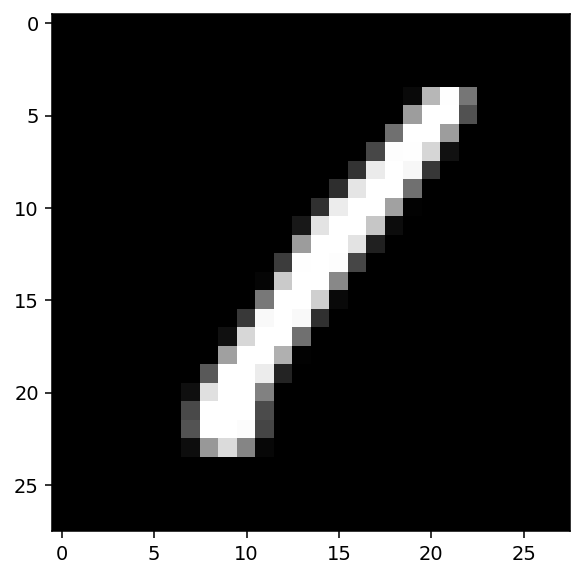

In [ ]:
plt.imshow(x[0], cmap='gray')

Получается, что действительно сопоставили $x_0$ и $u^*$ из гиперкуба

ПРОВЕРИТЬ, ПОЧЕМУ НЕКОТОРЫЕ КАРТИНКИ НЕ ОПТИМИЗИРУЮТСЯ

In [ ]:
noises = torch.randn((100, 1, 28, 28)).to(device)

with torch.no_grad():
    ddim_dif_imgs = ddim(noises, n_steps=50)

(np.float64(-0.5), np.float64(279.5), np.float64(279.5), np.float64(-0.5))

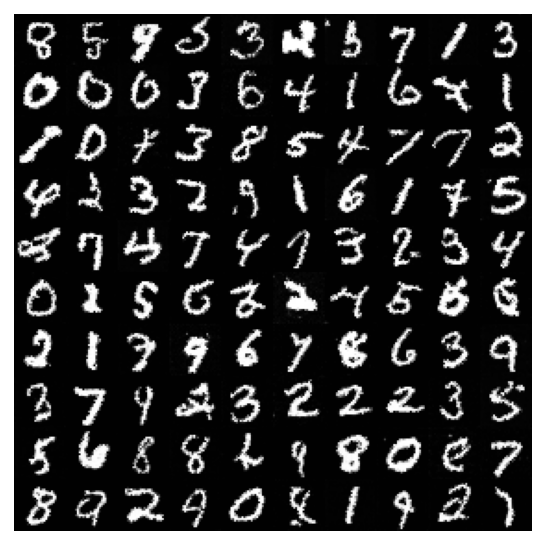

In [ ]:
grid = make_grid(
    ddim_dif_imgs[:100], value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
fig1 = plt.gcf()
plt.imshow(img)
plt.axis('off')
# fig1.savefig('/content/Images/ddim_samples_from_1.png')

In [ ]:
noises_np = noises.detach().cpu().numpy()
ddim_imgs, _ = ddim_init.sampling(initial_noise=noises_np)

  0%|          | 0/50 [00:00<?, ?it/s]

(np.float64(-0.5), np.float64(279.5), np.float64(279.5), np.float64(-0.5))

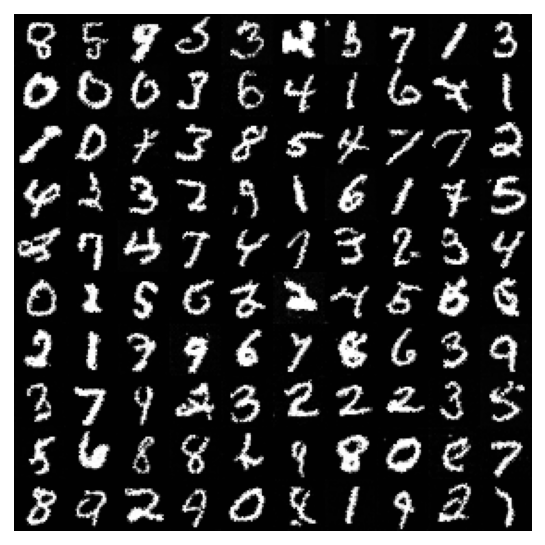

In [ ]:
grid = make_grid(
    torch.from_numpy(ddim_imgs[:100]), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
fig1 = plt.gcf()
plt.imshow(img)
plt.axis('off')
# fig1.savefig('/content/Images/ddim_samples_from_1.png')

Вроде всё одинаково, без изменений

## Batched inversion

Works only for first image, next ones are blank

In [ ]:
train_csv_path = '/content/train.csv'
batch_size = 128

trainset = CustomMnistDataset(train_csv_path)
data = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=False, drop_last=False
)

  0%|          | 0/300 [00:00<?, ?it/s]

best_loss: 2.5157089233398438


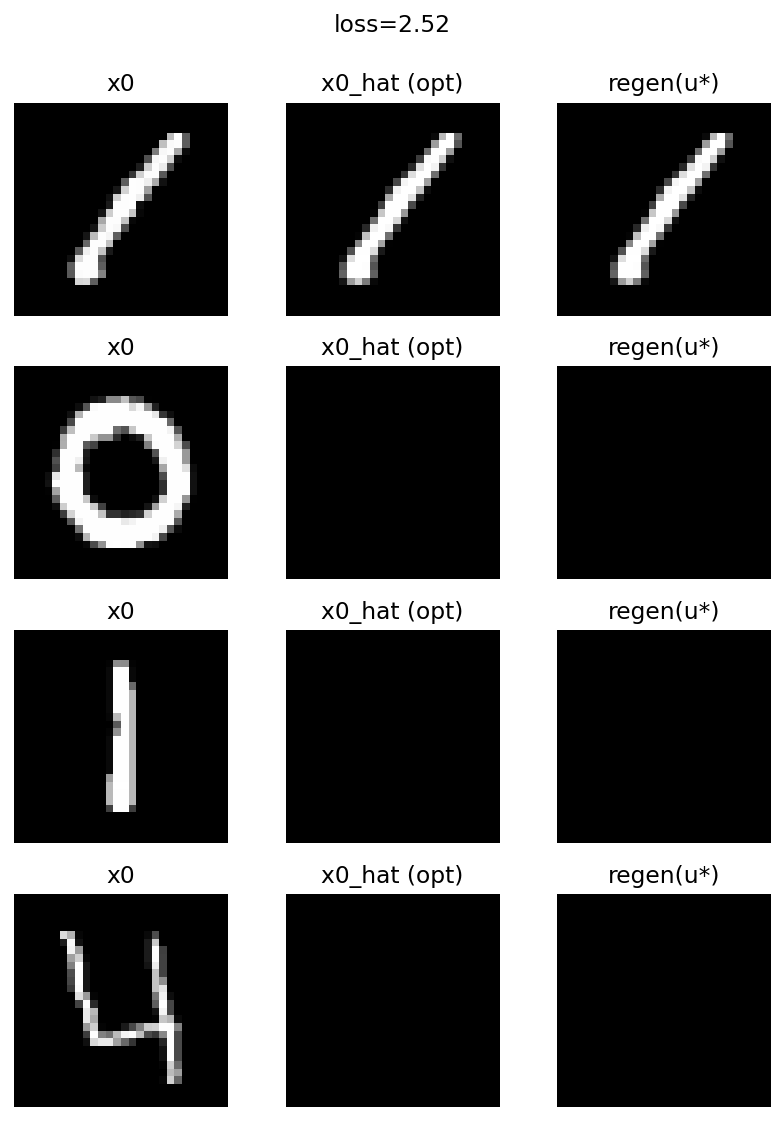

Embedding MSE:  opt=2.499817  regen=2.499817
Pixel MSE:      opt=0.317799  regen=0.317799
Regen vs opt MSE: 0.000000


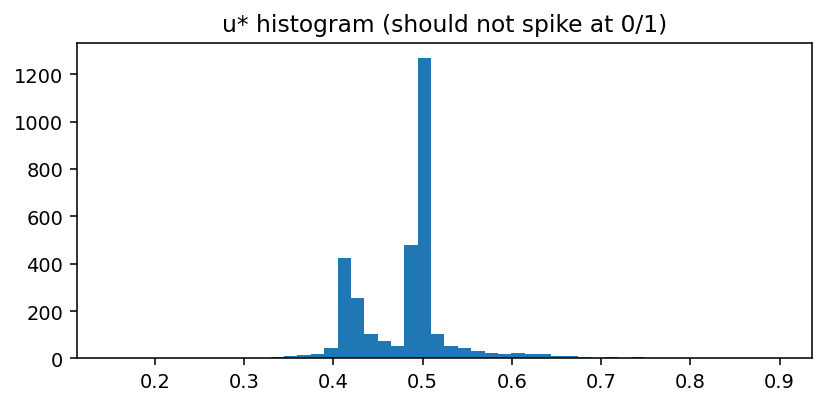

In [ ]:
unet = torch.load('/content/drive/MyDrive/cursach-hse/ddpm_unet.pth', weights_only=False)

ae = Autoencoder(latent_dims=100).to(device)
ae.load_state_dict(torch.load(os.path.join(data_path, 'compare_two_unseen', 'ae_100dim_new.pth'), weights_only=True))

ddim = DDIMDiffable(T=1000, model=unet, device=device)

x0_big = next(iter(data)).to(device)          # (128,1,28,28)
x0 = x0_big[:4].contiguous()                 # invert 16 images (change to 8 if needed)

u_star, z_star, x0_hat, best_loss, hist = invert_batch_to_cube(
    x0=x0,
    ddim=ddim,
    ae=ae,
    n_steps=50,
    iters=300,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
    eps_cube=1e-6,
    clamp_logits=8.0,
)

print("best_loss:", best_loss)
show_triplets(x0, x0_hat, u_star, ddim, n_steps=50, max_n=8, title=f"loss={best_loss:.3g}")
print_metrics(x0, x0_hat, u_star, ddim, ae, n_steps=50)
plot_cube_hist(u_star, title="u* histogram (should not spike at 0/1)")

# Процедура в гиперкубе

In [ ]:
orig_embds = np.load(os.path.join(data_path, 'distances_distribution', 'train_embds_42000.npy'))
orig_embds.shape

(42000, 100)

In [ ]:
ddim_embds = np.load(os.path.join(data_path, 'ddim_fake_embds_42000.npy'))
ddim_fake_imgs = np.load(os.path.join(data_path, 'ddim_imgs_42000.npy'))
ddim_noises_norm = np.load(os.path.join(data_path, 'ddim_noises_42000_norm.npy'))
ddim_noises_unif = np.load(os.path.join(data_path, 'ddim_noises_42000_unif.npy'))

In [ ]:
ddim_distances = euclidean_distances(orig_embds[random_idx][None, ...], ddim_embds)
ddim_distances = ddim_distances.squeeze()
closest_ddim_idx = np.argmin(ddim_distances)

Text(0.5, 1.0, 'Closest DDIM sample to orig point, dist=9.635')

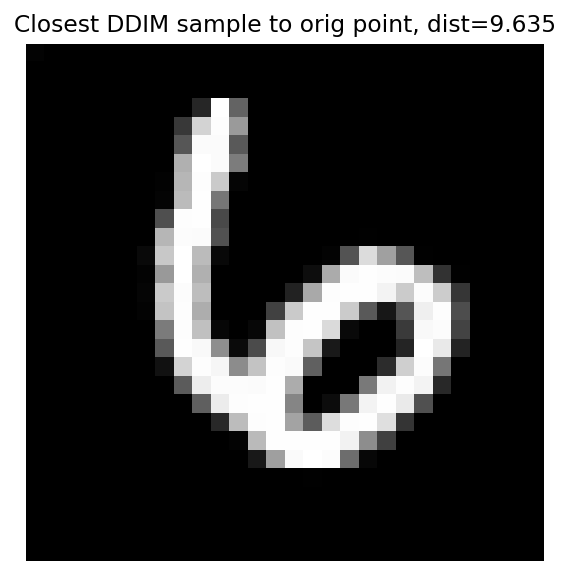

In [ ]:
fig1 = plt.gcf()
plt.imshow(ddim_fake_imgs[closest_ddim_idx].reshape(28, 28), cmap='gray')
plt.axis('off')
plt.title(f'Closest DDIM sample to orig point, dist={ddim_distances[closest_ddim_idx]:.3f}')
# fig1.savefig('/content/Images/ddim_1.png')

In [ ]:
ddim_closest_noise_norm = ddim_noises_norm[closest_ddim_idx].reshape(28, 28)
ddim_closest_noise_norm = np.expand_dims(ddim_closest_noise_norm, axis=(0, 1))

ddim_closest_noise_norm.shape

(1, 1, 28, 28)

In [ ]:
# Это для двух моделей
# # в гиперкубе, на выходе шумы из нормального распределения
# # initial_point --> random_point: alpha * random_point + (1 - alpha) * initial_point
# def get_additive_noises(cfm_initial_noise, ddim_initial_noise, eps=1e-2, it=100):
#     cfm_noises = [cfm_initial_noise]
#     ddim_noises = [ddim_initial_noise]

#     add_noise_vec = np.random.randn(*cfm_initial_noise.shape)
#     add_noise_vec = norm.cdf(add_noise_vec)

#     # transform initial noise to [0,1]
#     u_cfm_noise = norm.cdf(cfm_initial_noise)
#     u_ddim_noise = norm.cdf(ddim_initial_noise)

#     alphas = np.linspace(0, 1, it)

#     def get_next_noise(initial_noise, add_noise_vec, alpha):
#         new_u_noise = alpha * add_noise_vec + (1 - alpha) * initial_noise
#         # new_u_noise = np.clip(new_noise, 0, 1)
#         return norm.ppf(new_u_noise).astype(np.float32)

#     for alpha in alphas[1:]:
#         cfm_new_noise = get_next_noise(u_cfm_noise, add_noise_vec, alpha)
#         cfm_noises.append(cfm_new_noise)

#         ddim_new_noise = get_next_noise(u_ddim_noise, add_noise_vec, alpha)
#         ddim_noises.append(ddim_new_noise)

#     return np.vstack(cfm_noises), np.vstack(ddim_noises), add_noise_vec

In [ ]:
# в гиперкубе, на выходе шумы из нормального распределения
# initial_point --> random_point: alpha * random_point + (1 - alpha) * initial_point
def get_additive_noises(ddim_initial_noise, eps=1e-2, it=100):
    ddim_noises = [ddim_initial_noise]

    add_noise_vec = np.random.randn(*ddim_initial_noise.shape)
    add_noise_vec = norm.cdf(add_noise_vec)

    # transform initial noise to [0,1]
    u_ddim_noise = norm.cdf(ddim_initial_noise)

    alphas = np.linspace(0, 1, it)

    def get_next_noise(initial_noise, add_noise_vec, alpha):
        new_u_noise = alpha * add_noise_vec + (1 - alpha) * initial_noise
        # new_u_noise = np.clip(new_noise, 0, 1)
        return norm.ppf(new_u_noise).astype(np.float32)

    for alpha in alphas[1:]:
        ddim_new_noise = get_next_noise(u_ddim_noise, add_noise_vec, alpha)
        ddim_noises.append(ddim_new_noise)

    return np.vstack(ddim_noises), add_noise_vec

In [ ]:
model = torch.load('/content/drive/MyDrive/cursach-hse/ddpm_unet.pth', weights_only=False)

ddim_init = DDIM(1000, model, device)

In [ ]:
ddim_noises, direction_noise_vec = get_additive_noises(ddim_closest_noise_norm, it=100)

In [ ]:
ddim_imgs_from_add_noise, _ = ddim_init.sampling(initial_noise=ddim_noises)

  0%|          | 0/50 [00:00<?, ?it/s]

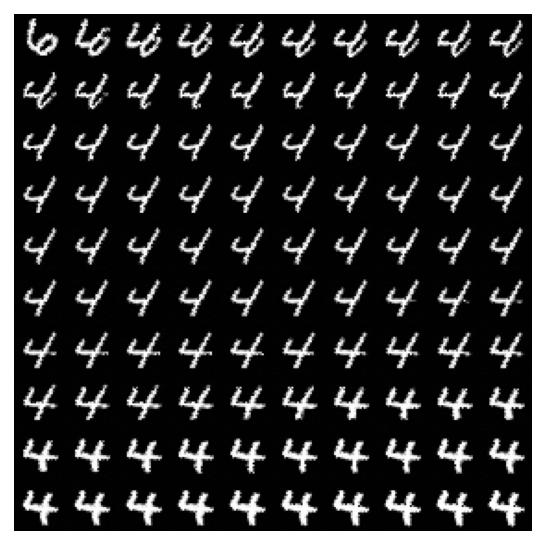

In [ ]:
grid = make_grid(
    torch.from_numpy(ddim_imgs_from_add_noise[:100]), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
fig1 = plt.gcf()
plt.axis('off')
plt.imshow(img)
# fig1.savefig('/content/Images/ddim_samples_from_1.png')

In [ ]:
ddim_imgs_from_add_noise = torch.from_numpy(ddim_imgs_from_add_noise).to(device)
ddim_new_embds = ae.encoder(ddim_imgs_from_add_noise)

In [ ]:
ddim_new_embds = ddim_new_embds.to('cpu').detach().numpy()

In [ ]:
ddim_distances_to_orig = euclidean_distances(ddim_new_embds, orig_embds)
ddim_distances_to_orig = ddim_distances_to_orig.squeeze()

In [ ]:
closest_ddim_distances = np.min(ddim_distances_to_orig, axis=1)
idx_closest_ddim_distances = np.argmin(ddim_distances_to_orig, axis=1)
closest_ddim_distances.shape, idx_closest_ddim_distances.shape

((100,), (100,))

In [ ]:
def get_transition_moments(idxs):
    moments = []
    for i in range(1, len(idxs)):
        if idxs[i] != idxs[i-1]:
            moments.append(i)
    return moments


def get_closest_orig_samples(idxs, dataset):
    samples = []
    for i in idxs:
        unseen_image = dataset.iloc[i].filter(regex='pixel').values
        unseen_image = np.reshape(unseen_image, (28, 28)).astype(np.uint8)
        samples.append(unseen_image)

    return np.stack(samples)

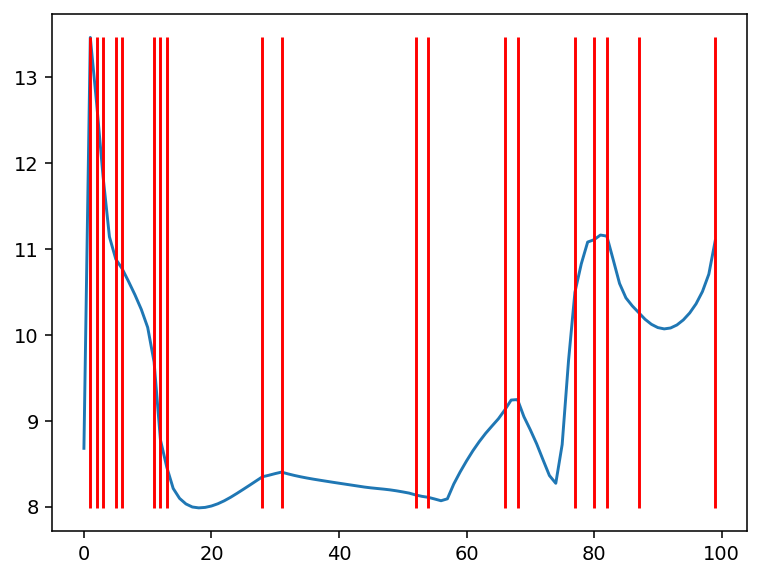

In [ ]:
arange = np.arange(100)
ddim_transition_moments = get_transition_moments(idx_closest_ddim_distances)

plt.plot(arange, closest_ddim_distances)
plt.vlines(get_transition_moments(idx_closest_ddim_distances), ymin=np.min(closest_ddim_distances), ymax=np.max(closest_ddim_distances), colors='red')

plt.show()

In [ ]:
mnist_df = pd.read_csv('train.csv')

In [ ]:
closest_images_to_ddim = get_closest_orig_samples(idx_closest_ddim_distances, mnist_df)

(np.float64(-0.5), np.float64(279.5), np.float64(279.5), np.float64(-0.5))

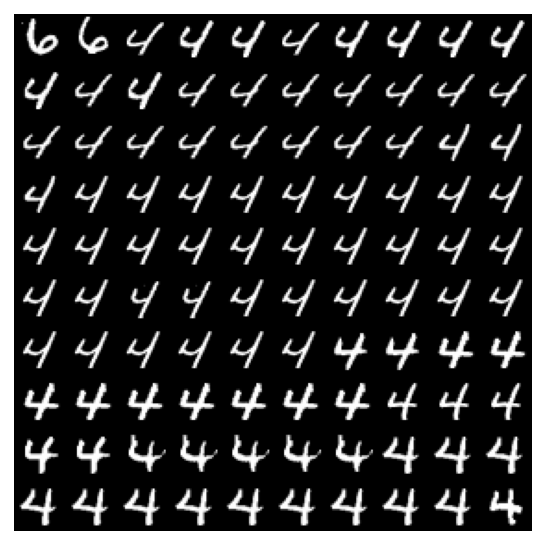

In [ ]:
grid = make_grid(
    torch.from_numpy(closest_images_to_ddim[:100]).unsqueeze(1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
fig1 = plt.gcf()
plt.imshow(img)
plt.axis('off')

In [ ]:
idx_closest_ddim_distances

array([35533, 13372,  4410, 38341, 38341,  4410, 38341, 38341, 38341,
       38341, 38341, 16258, 38341, 16258, 16258, 16258, 16258, 16258,
       16258, 16258, 16258, 16258, 16258, 16258, 16258, 16258, 16258,
       16258, 10444, 10444, 10444, 24576, 24576, 24576, 24576, 24576,
       24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576,
       24576, 24576, 24576, 24576, 24576, 24576, 24576, 22861, 22861,
       24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576,
       24576, 24576, 24576, 24607, 24607, 20421, 20421, 20421, 20421,
       20421, 20421, 20421, 20421, 20421,  5767,  5767,  5767,  8427,
        8427, 14131, 14131, 14131, 14131, 14131, 24998, 24998, 24998,
       24998, 24998, 24998, 24998, 24998, 24998, 24998, 24998, 24998,
       21465])

In [ ]:
ddim_transition_moments

[1, 2, 3, 5, 6, 11, 12, 13, 28, 31, 52, 54, 66, 68, 77, 80, 82, 87, 99]

In [ ]:
unique_closest_idxs = np.unique(idx_closest_ddim_distances)
unique_closest_idxs

array([ 4410,  5767,  8427, 10444, 13372, 14131, 16258, 20421, 21465,
       22861, 24576, 24607, 24998, 35533, 38341])

In [ ]:
x1 = torch.vstack([
    trainset[unique_closest_idxs[0]].unsqueeze(0),
    trainset[unique_closest_idxs[1]].unsqueeze(0),
    trainset[unique_closest_idxs[2]].unsqueeze(0),
    trainset[unique_closest_idxs[3]].unsqueeze(0),
]).to(device)

n_iters = 150  # 300 is good

u_star1, z_star1, x0_hat1, best_loss1, hist1 = invert_batch_to_cube(
    x0=x1,
    ddim=ddim,
    ae=ae,
    n_steps=50,
    iters=n_iters,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
)

print("best_loss:", best_loss)

  0%|          | 0/150 [00:00<?, ?it/s]

25 1.1099778413772583 0.1452654004096985
50 0.38023337721824646 0.056891947984695435
75 0.08583097159862518 0.017046384513378143
100 0.04109641909599304 0.009571249596774578
125 0.030923523008823395 0.008019629865884781
150 0.025175895541906357 0.007108813617378473
best_loss: 0.036655813455581665


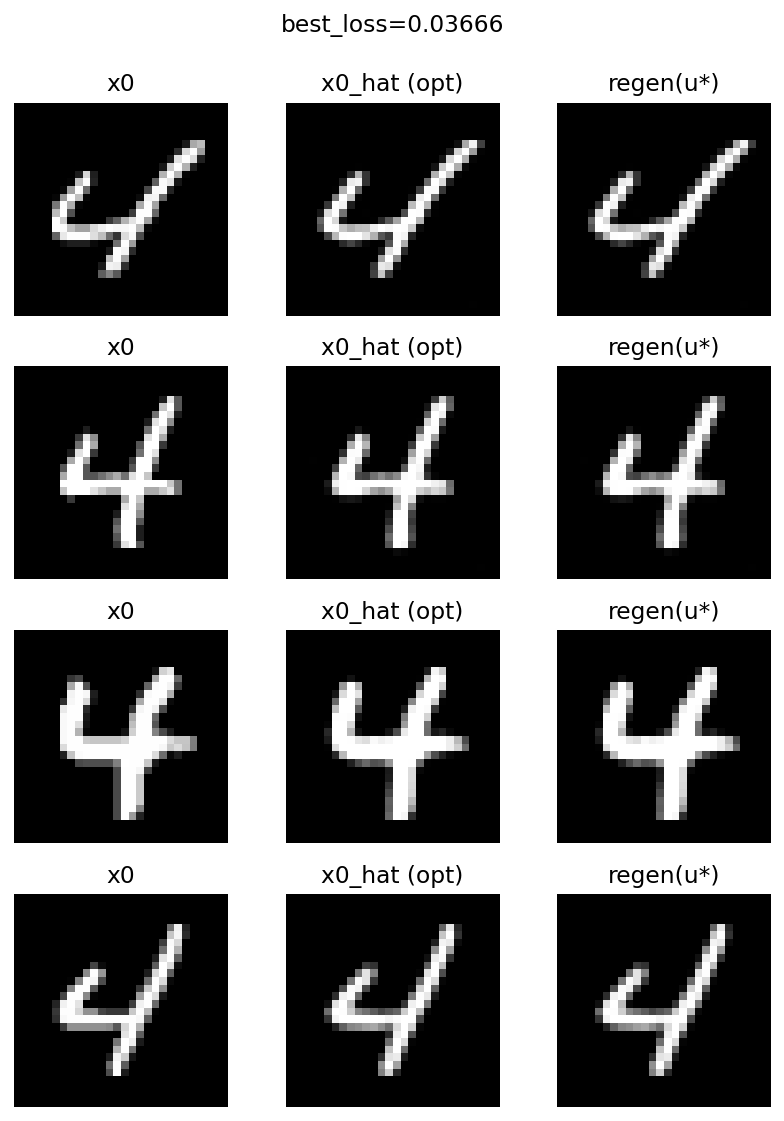

In [ ]:
show_triplets(x1, x0_hat1, u_star1, ddim, n_steps=50, max_n=8, title=f"best_loss={best_loss:.4g}")

In [ ]:
u_star1.shape

torch.Size([4, 1, 28, 28])

In [ ]:
u_star_first5 = torch.vstack([u_star, u_star1])

In [ ]:
u_star_first5 = u_star_first5.detach().cpu().numpy()

In [ ]:
np.save('u_star_first5.npy', u_star_first5)

In [ ]:
ddim_imgs_from_add_noise_np = ddim_imgs_from_add_noise.detach().cpu().numpy()

In [ ]:
np.save('ddim_imgs_from_add_noise.npy', ddim_imgs_from_add_noise_np)

In [ ]:
x2 = torch.vstack([
    trainset[unique_closest_idxs[4]].unsqueeze(0),
    trainset[unique_closest_idxs[5]].unsqueeze(0),
    trainset[unique_closest_idxs[6]].unsqueeze(0),
    trainset[unique_closest_idxs[7]].unsqueeze(0),
]).to(device)

n_iters = 150  # 300 is good

u_star2, z_star2, x0_hat2, best_loss2, hist2 = invert_batch_to_cube(
    x0=x2,
    ddim=ddim,
    ae=ae,
    n_steps=50,
    iters=n_iters,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
)

print("best_loss:", best_loss)

  0%|          | 0/150 [00:00<?, ?it/s]

25 1.6973448991775513 0.23435020446777344
50 0.7314973473548889 0.10423930734395981
75 0.1440824419260025 0.02794516831636429
100 0.07266532629728317 0.017168406397104263
125 0.04854011535644531 0.013365504331886768
150 0.03561340272426605 0.011256656609475613
best_loss: 0.036655813455581665


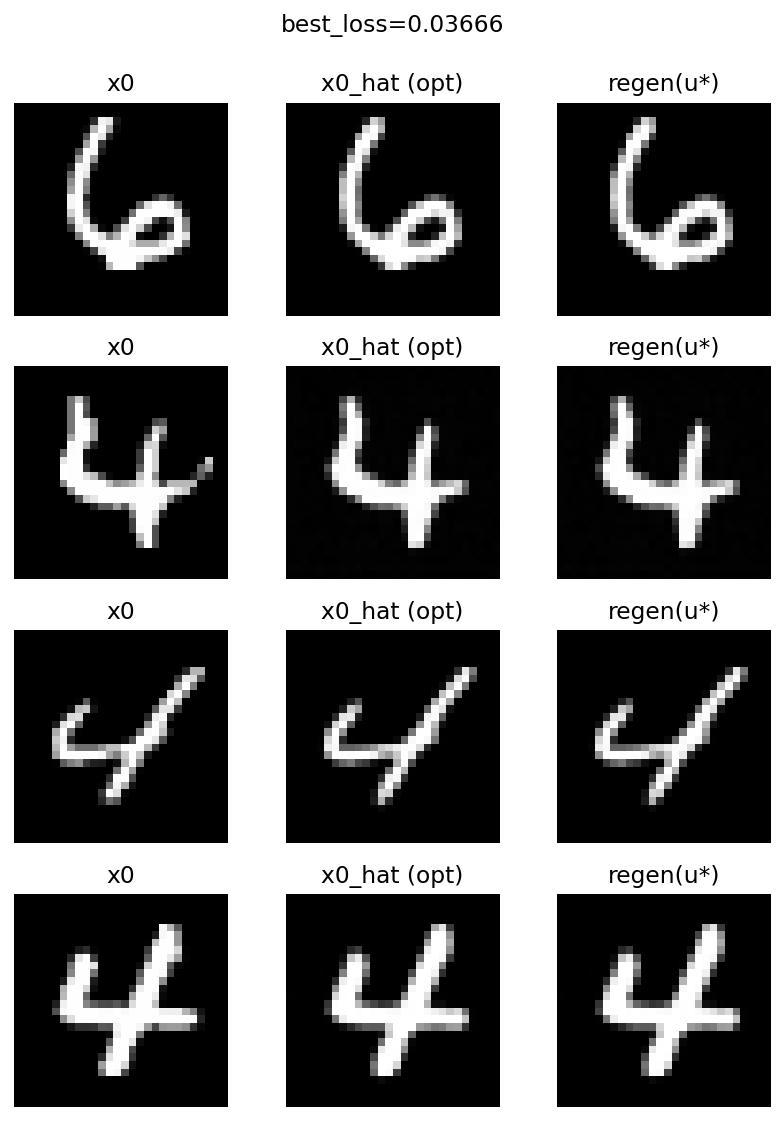

In [ ]:
show_triplets(x2, x0_hat2, u_star2, ddim, n_steps=50, max_n=8, title=f"best_loss={best_loss:.4g}")

In [ ]:
x3 = torch.vstack([
    trainset[unique_closest_idxs[8]].unsqueeze(0),
    trainset[unique_closest_idxs[9]].unsqueeze(0),
    trainset[unique_closest_idxs[10]].unsqueeze(0),
    trainset[unique_closest_idxs[11]].unsqueeze(0),
]).to(device)

n_iters = 150  # 300 is good

u_star3, z_star3, x0_hat3, best_loss3, hist3 = invert_batch_to_cube(
    x0=x3,
    ddim=ddim,
    ae=ae,
    n_steps=50,
    iters=n_iters,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
)

print("best_loss:", best_loss)

  0%|          | 0/150 [00:00<?, ?it/s]

25 2.2494232654571533 0.3026997745037079
50 1.746346116065979 0.21744467318058014
75 1.0068359375 0.13406753540039062
100 0.7861323356628418 0.10504728555679321
125 0.7268515825271606 0.09677169471979141
150 0.6423858404159546 0.08560260385274887
best_loss: 0.036655813455581665


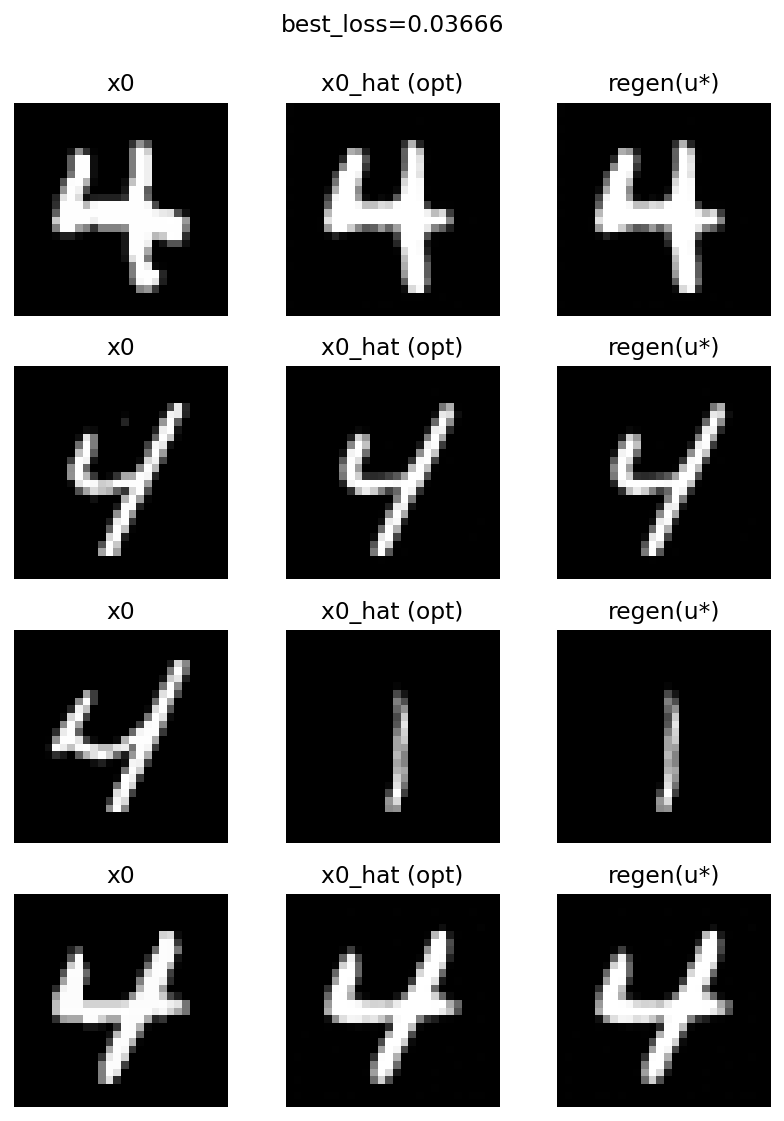

In [ ]:
show_triplets(x3, x0_hat3, u_star3, ddim, n_steps=50, max_n=8, title=f"best_loss={best_loss:.4g}")

In [ ]:
x4 = torch.vstack([
    trainset[unique_closest_idxs[12]].unsqueeze(0),
    trainset[unique_closest_idxs[13]].unsqueeze(0),
    trainset[unique_closest_idxs[14]].unsqueeze(0),
]).to(device)

n_iters = 150  # 300 is good

u_star4, z_star4, x0_hat4, best_loss4, hist4 = invert_batch_to_cube(
    x0=x4,
    ddim=ddim,
    ae=ae,
    n_steps=50,
    iters=n_iters,
    lr=5e-2,
    lambda_pix=0.05,
    lambda_prior=1e-4,
)

print("best_loss:", best_loss)

  0%|          | 0/150 [00:00<?, ?it/s]

25 1.6743237972259521 0.2178676873445511
50 1.0820778608322144 0.1428862363100052
75 0.12592467665672302 0.0281810462474823
100 0.05906423553824425 0.014254174195230007
125 0.04315582290291786 0.011431347578763962
150 0.035327281802892685 0.010256881825625896
best_loss: 0.036655813455581665


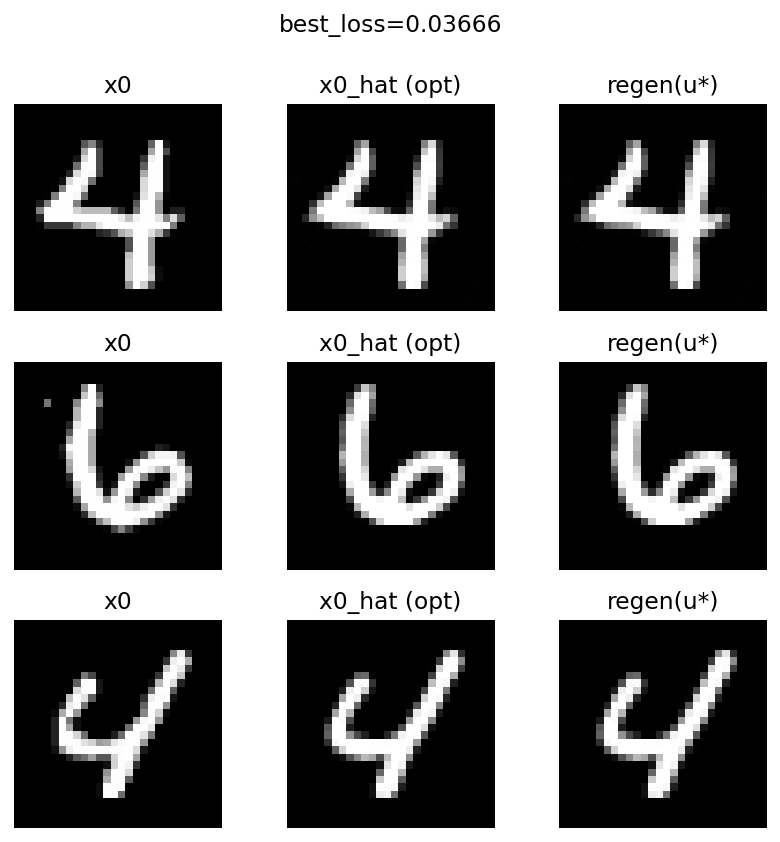

In [ ]:
show_triplets(x4, x0_hat4, u_star4, ddim, n_steps=50, max_n=8, title=f"best_loss={best_loss:.4g}")

In [ ]:
u_star_all = torch.vstack([u_star, u_star1, u_star2, u_star3, u_star4])

In [ ]:
u_star_all = u_star_all.detach().cpu().numpy()
np.save('u_star_all.npy', u_star_all)

In [ ]:
u_star_all.shape

(16, 1, 28, 28)

In [ ]:
ddim_noises_u = norm.cdf(ddim_noises)

In [ ]:
np.save('ddim_noises_u_last.npy', ddim_noises_u)
np.save('ddim_noises_last.npy', ddim_noises)

In [ ]:
idx_closest_ddim_distances

array([35533, 13372,  4410, 38341, 38341,  4410, 38341, 38341, 38341,
       38341, 38341, 16258, 38341, 16258, 16258, 16258, 16258, 16258,
       16258, 16258, 16258, 16258, 16258, 16258, 16258, 16258, 16258,
       16258, 10444, 10444, 10444, 24576, 24576, 24576, 24576, 24576,
       24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576,
       24576, 24576, 24576, 24576, 24576, 24576, 24576, 22861, 22861,
       24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576, 24576,
       24576, 24576, 24576, 24607, 24607, 20421, 20421, 20421, 20421,
       20421, 20421, 20421, 20421, 20421,  5767,  5767,  5767,  8427,
        8427, 14131, 14131, 14131, 14131, 14131, 24998, 24998, 24998,
       24998, 24998, 24998, 24998, 24998, 24998, 24998, 24998, 24998,
       21465])

In [ ]:
unique_closest_idxs

array([ 4410,  5767,  8427, 10444, 13372, 14131, 16258, 20421, 21465,
       22861, 24576, 24607, 24998, 35533, 38341])

In [ ]:
np.where(unique_closest_idxs == 35533)[0][0]

AttributeError: 'tuple' object has no attribute 'item'

In [ ]:
hypercube_distances = []

for i, idx in enumerate(idx_closest_ddim_distances):
    act_idx = np.where(unique_closest_idxs == idx)[0][0]
    dist = np.sqrt(np.sum((ddim_noises_u[i].flatten() - u_star_all[act_idx].flatten()) ** 2))
    hypercube_distances.append(dist)

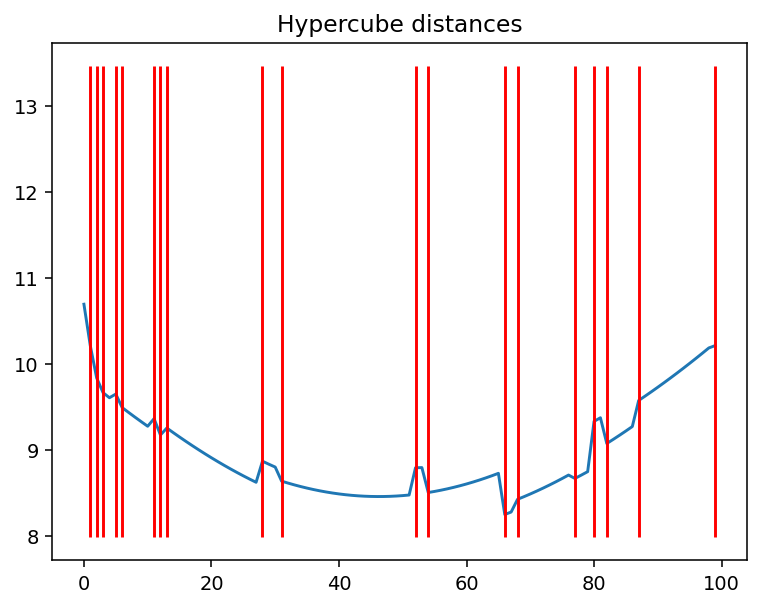

In [ ]:
arange = np.arange(100)
plt.plot(arange, hypercube_distances)
plt.vlines(get_transition_moments(idx_closest_ddim_distances), ymin=np.min(closest_ddim_distances), ymax=np.max(closest_ddim_distances), colors='red')
plt.title('Hypercube distances')
plt.show()

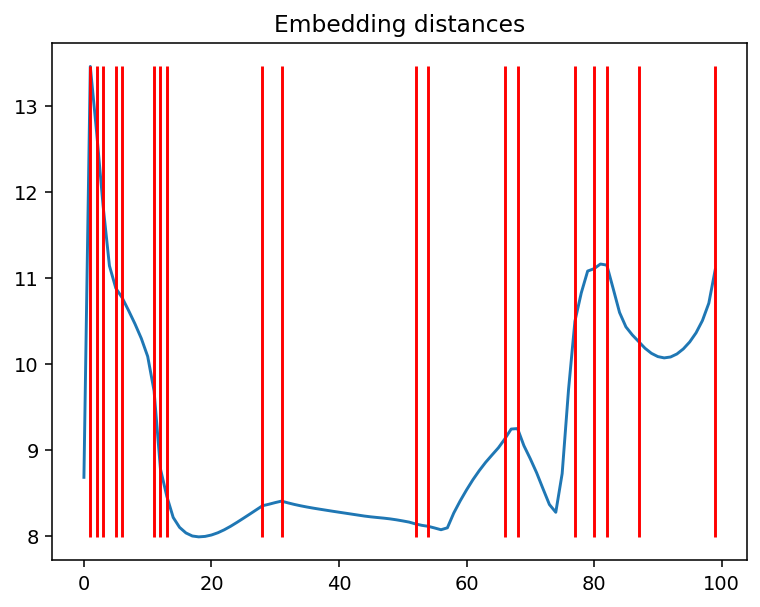

In [ ]:
plt.plot(arange, closest_ddim_distances)
plt.vlines(get_transition_moments(idx_closest_ddim_distances), ymin=np.min(closest_ddim_distances), ymax=np.max(closest_ddim_distances), colors='red')
plt.title('Embedding distances')
plt.show()